In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns            
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from helpers import find_max_feature

In [2]:
lga_names = pd.read_excel(
    '2021Census_geog_desc_1st_2nd_3rd_release.xlsx',
    sheet_name='2021_ASGS_Non_ABS_Structures'
)

lga_names = lga_names[lga_names['ASGS_Structure'] == 'LGA'][['Census_Code_2021', 'Census_Name_2021']]
lga_names.columns = ['LGA_CODE_2021', 'LGA_NAME']
lga_names = lga_names.set_index("LGA_CODE_2021")


In [3]:
median_df = pd.read_csv('NSW-LGA/2021Census_G02_NSW_LGA.csv')
median_df = median_df.set_index("LGA_CODE_2021")
median_df = median_df.drop(columns=["Median_tot_prsnl_inc_weekly", "Median_tot_fam_inc_weekly"])
median_df = median_df[median_df['Median_tot_hhd_inc_weekly'] != 0] # drop dodgy LGA columns that don't correspond to a real LGA 
median_df = median_df.join(lga_names)


In [4]:
find_max_feature('Median_age_persons', median_df, "median age")
find_max_feature('Median_tot_hhd_inc_weekly', median_df, "median total household weekly income")

The LGA with the highest median age is Tenterfield with a median age of 55
The LGA with the highest median total household weekly income is Woollahra with a median total household weekly income of 3192


In [14]:
otherfeaturesdf = pd.read_csv('NSW-LGA/2021Census_G01_NSW_LGA.csv')
otherfeaturesdf = otherfeaturesdf.set_index("LGA_CODE_2021")
otherfeaturesdf['pct_aged_15_24'] = (otherfeaturesdf['Age_15_19_yr_P'] + otherfeaturesdf['Age_20_24_yr_P'])/ otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_born_australia']   = otherfeaturesdf['Birthplace_Australia_P'] / otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_english_only']     = otherfeaturesdf['Lang_used_home_Eng_only_P'] / otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_completed_yr12']   = otherfeaturesdf['High_yr_schl_comp_Yr_12_eq_P'] / otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_low_education']    = otherfeaturesdf['High_yr_schl_comp_Yr_8_belw_P'] / otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_aged_65_plus']     = (otherfeaturesdf['Age_65_74_yr_P'] + otherfeaturesdf['Age_75_84_yr_P'] + otherfeaturesdf['Age_85ov_P']) / otherfeaturesdf['Tot_P_P']
otherfeaturesdf['pct_indigenous']       = otherfeaturesdf['Indigenous_P_Tot_P'] / otherfeaturesdf['Tot_P_P']
otherfeaturesdf = otherfeaturesdf[["pct_aged_15_24", "pct_born_australia", "pct_english_only", "pct_completed_yr12", "pct_low_education", "pct_aged_65_plus", "pct_indigenous"]]

In [18]:
updateddf = median_df.join(otherfeaturesdf)
updateddf = updateddf.drop(columns=['Median_age_persons', 'Median_mortgage_repay_monthly',
       'Median_rent_weekly', 'Average_num_psns_per_bedroom', 'Average_household_size']) 
print(updateddf.columns)
print(len(updateddf))
updateddf.describe()

Index(['Median_tot_hhd_inc_weekly', 'LGA_NAME', 'pct_aged_15_24',
       'pct_born_australia', 'pct_english_only', 'pct_completed_yr12',
       'pct_low_education', 'pct_aged_65_plus', 'pct_indigenous'],
      dtype='object')
129


,Median_tot_hhd_inc_weekly,pct_aged_15_24,pct_born_australia,pct_english_only,pct_completed_yr12,pct_low_education,pct_aged_65_plus,pct_indigenous
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,1601.573643,0.108834,0.754567,0.796556,0.376291,0.038050,0.209017,0.071545
std,505.730285,0.017266,0.131743,0.157606,0.133546,0.014442,0.053936,0.074405
min,885.000000,0.057087,0.362292,0.233855,0.186087,0.006352,0.096332,0.002410
25%,1236.000000,0.098394,0.733775,0.784020,0.277909,0.030028,0.166810,0.030352
50%,1465.000000,0.107226,0.813296,0.866444,0.326522,0.039477,0.206897,0.054988
75%,1766.000000,0.119154,0.841097,0.887950,0.440911,0.046679,0.245178,0.082720
max,3192.000000,0.169953,0.890053,0.946127,0.740025,0.080580,0.331987,0.514012


In [16]:
updateddf.to_csv('bigger_df_clean', index=True)

In [17]:
find_max_feature('pct_born_australia', updateddf, "percentage of people born in Australia")

The LGA with the highest percentage of people born in Australia is Dungog with a percentage of people born in Australia of 0.8900534535164029


[0.59906684 0.8756369  0.83958118 0.8409332  0.71938075] 0.7749197753403729 0.10265636733594774
for alpha=0.01: scores mean = 0.775, scores sd = 0.102
for alpha=0.1: scores mean = 0.776, scores sd = 0.101
for alpha=1: scores mean = 0.782, scores sd = 0.090
for alpha=10: scores mean = 0.787, scores sd = 0.068
for alpha=100: scores mean = 0.713, scores sd = 0.052
pct_low_education    -142.913669
pct_aged_65_plus     -142.604991
pct_born_australia    -30.149295
pct_indigenous        -27.789528
pct_aged_15_24         20.985694
pct_english_only       75.738270
pct_completed_yr12    227.142779
dtype: float64
pct_low_education: 0.542
pct_completed_yr12: 0.214
pct_aged_65_plus: 0.116
pct_indigenous: 0.074
pct_aged_15_24: 0.024
pct_born_australia: 0.016
pct_english_only: 0.014
[0.66744416 0.82741317 0.91543701 0.91412205 0.85114992] 0.8351132630720546 0.09069033928365358
MAE: $138


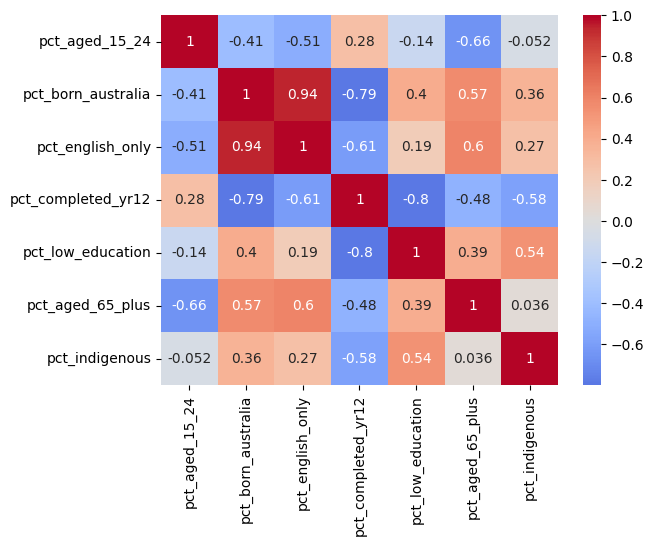

pct_aged_15_24        0.350038
pct_born_australia   -0.590859
pct_english_only     -0.428835
pct_completed_yr12    0.846920
pct_low_education    -0.805942
pct_aged_65_plus     -0.605426
pct_indigenous       -0.467978
dtype: float64

In [38]:
X = updateddf.drop(columns=['LGA_NAME', 'Median_tot_hhd_inc_weekly'])
y = updateddf['Median_tot_hhd_inc_weekly']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Simple Ordinary Least Squares regression
pipe_ols = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
scores_ols = cross_val_score(pipe_ols, X, y, cv=kf, scoring='r2')
print(scores_ols, scores_ols.mean(), scores_ols.std())

# Ridge regression with various alphas
for a in [0.01, 0.1, 1, 10, 100]:
    p = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=a))])
    s = cross_val_score(p, X, y, cv=kf, scoring='r2')
    print(f"for alpha={a}: scores mean = {s.mean():.3f}, scores sd = {s.std():.3f}")

# Alpha=10 gave the best CV score (0.787), so refit on all data to
# inspect coefficients. Features are standardised, so magnitudes are
# directly comparable across features and signs show direction of effect.
pipe_ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10))])
pipe_ridge.fit(X, y)
print(pd.Series(pipe_ridge.named_steps['model'].coef_, index=X.columns).sort_values())

# Random forest 
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])
pipe_rf.fit(X,y)
importances = pipe_rf.named_steps['model'].feature_importances_
for name, imp in sorted(zip(X.columns, importances), key=lambda t: t[1], reverse=True):
    print(f"{name}: {imp:.3f}")

scores_rf = cross_val_score(pipe_rf, X, y, cv=kf, scoring='r2')
print(scores_rf, scores_rf.mean(), scores_rf.std())

mae = cross_val_score(pipe_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"MAE: ${-mae.mean():.0f}")

sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()
X.corrwith(y)